In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    # Directories
    'runs_root': 'runs/',
    'output_dir': 'plots/',  # <<< NEW: Directory to save plots
    
    # Training settings
    'total_steps': 10000,
    'window_size': 500,  # First/last N steps to plot
    'smoothing_window': 20,  # Moving average window
    
    # Metrics to plot
    'metric': 'spectral_loss',  # Primary metric
    
    # Filter type to analyze ('conv' or 'arma64x64')
    'filter_type': 'conv',  # <<< NEW: Change to 'arma64x64' to analyze ARMA models
    
    # Visual settings
    'real_ir_color': '#1f77b4',      # Blue (not used here, but keeping consistent)
    'learned_ir_linewidth': 2.5,
    'learned_ir_alpha': 0.95,
    'y_axis_first_500': (0, 40),  # Fixed y-axis for first 500 steps
    'y_axis_last_500': (0, 10),   # Fixed y-axis for last 500 steps
    
    # Plot saving settings
    'save_dpi': 300,  # <<< NEW: DPI for saved plots
    'save_format': 'png',  # <<< NEW: Format for saved plots (png, pdf, svg, etc.)
    
    # Variations to analyze
    'variations': [
        'Bernardel_ear_norm',
        'Bernardel_ff_norm',
        'StradCopy_ear_norm',
        'StradCopy_ff_norm',
        'Sundin_ear_norm',
        'Sundin_ff_norm',
    ],
    
    # Model groups for comparison
    'standard_models': [
        {'suffix': '__std', 'label': 'Standard (Baseline)', 'color': '#2ca02c', 'linestyle': '-'},
        {'suffix': '__std_svl_w1', 'label': 'Standard + SVL(w=1)', 'color': '#ff7f0e', 'linestyle': '--'},
        {'suffix': '__std_svl_w10', 'label': 'Standard + SVL(w=10)', 'color': '#d62728', 'linestyle': '-.'},
    ],
    
    'physics_models': [
        {'suffix': '__vio', 'label': 'Physics (Baseline)', 'color': '#9467bd', 'linestyle': '-'},
        {'suffix': '__vio_vpl_w1', 'label': 'Physics + VPL(w=1)', 'color': '#8c564b', 'linestyle': '--'},
        {'suffix': '__vio_vpl_w10', 'label': 'Physics + VPL(w=10)', 'color': '#e377c2', 'linestyle': '-.'},  # <<< CHANGED from w100 to w10
    ],
}

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def ensure_output_dir(config=CONFIG):
    """Create output directory if it doesn't exist."""
    os.makedirs(config['output_dir'], exist_ok=True)

def print_header(title):
    """Print formatted section header."""
    print(f"\n{'='*80}")
    print(f"{title.upper()}")
    print(f"{'='*80}")

def get_run_name(variation, split, model_suffix, config=CONFIG):
    """Construct run name from variation, split, and model suffix."""
    # <<< MODIFIED: Insert filter type suffix if arma64x64
    filter_suffix = '__arma64x64' if config['filter_type'] == 'arma64x64' else ''
    return f"{variation}_{split}{filter_suffix}{model_suffix}"

def load_loss_data(run_name, window='all', config=CONFIG):
    """Load loss data from a run with optional windowing."""
    log_path = os.path.join(config['runs_root'], run_name, "loss_log.txt")
    
    if not os.path.exists(log_path):
        return None
    
    try:
        data = pd.read_csv(log_path)
        
        if data.empty or 'step' not in data.columns:
            return None
        
        if config['metric'] not in data.columns:
            return None
        
        # Apply windowing
        if window == 'first':
            data = data[data['step'] <= config['window_size']]
        elif window == 'last':
            min_step = config['total_steps'] - config['window_size'] + 1
            data = data[(data['step'] >= min_step) & (data['step'] <= config['total_steps'])]
        
        return None if data.empty else data
    
    except Exception as e:
        return None

def smooth_data(data, window_size):
    """Apply moving average smoothing."""
    if window_size < 2:
        return data
    return data.rolling(window=window_size, min_periods=1, center=True).mean()

def generate_plot_filename(variation, split, mode_label, config=CONFIG):
    """Generate filename for saving plots."""
    # Clean mode label for filename
    mode_clean = mode_label.replace(' ', '_').replace('(', '').replace(')', '').replace(':', '')
    
    # Add filter type to filename if arma64x64
    filter_suffix = f"_{config['filter_type']}" if config['filter_type'] == 'arma64x64' else ''
    
    filename = f"{variation}_{split}_{mode_clean}{filter_suffix}.{config['save_format']}"
    return os.path.join(config['output_dir'], filename)

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def plot_loss_comparison(variation, split, mode_label, model_specs, window, config=CONFIG):
    """Create loss evolution comparison plot."""
    
    # Ensure output directory exists
    ensure_output_dir(config)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    # Titles - <<< MODIFIED: Add filter type to title
    filter_label = f" [{config['filter_type'].upper()}]" if config['filter_type'] == 'arma64x64' else ''
    window_labels = {'first': f'First {config["window_size"]} Steps', 
                     'last': f'Last {config["window_size"]} Steps'}
    fig.suptitle(f'{variation} ({split} split) - {mode_label}{filter_label}', fontsize=16, fontweight='bold', y=0.98)
    
    # Track if any data was plotted
    has_data = False
    
    # Plot both windows
    for idx, window_type in enumerate(['first', 'last']):
        ax = axes[idx]
        ax.set_title(window_labels[window_type], fontsize=14, fontweight='bold')
        ax.set_xlabel('Step', fontsize=12)
        ax.set_ylabel('Spectral Loss', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Plot each model
        for model_spec in model_specs:
            run_name = get_run_name(variation, split, model_spec['suffix'], config)
            data = load_loss_data(run_name, window=window_type, config=config)
            
            if data is None:
                continue
            
            # Extract and smooth data
            steps = data['step'].values
            loss = data[config['metric']].values
            loss_smoothed = smooth_data(pd.Series(loss), config['smoothing_window']).values
            
            # Plot
            ax.plot(
                steps, loss_smoothed,
                color=model_spec['color'],
                linestyle=model_spec['linestyle'],
                linewidth=config['learned_ir_linewidth'],
                alpha=config['learned_ir_alpha'],
                label=model_spec['label']
            )
            
            has_data = True
        
        # Set fixed y-axis limits based on window type
        if window_type == 'first':
            ax.set_ylim(config['y_axis_first_500'])
        else:  # last
            ax.set_ylim(config['y_axis_last_500'])
        
        if has_data:
            ax.legend(fontsize=10, loc='best', framealpha=0.9)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # <<< NEW: Save the plot before showing
    if has_data:
        output_path = generate_plot_filename(variation, split, mode_label, config)
        plt.savefig(output_path, dpi=config['save_dpi'], bbox_inches='tight')
        print(f"    📊 Plot saved: {output_path}")
    
    plt.show()
    
    return has_data

# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def load_models_for_group(variation, split, model_specs, config=CONFIG):
    """Check which models in a group have data available."""
    available = []
    
    for spec in model_specs:
        run_name = get_run_name(variation, split, spec['suffix'], config)
        
        # Check both windows
        data_first = load_loss_data(run_name, window='first', config=config)
        data_last = load_loss_data(run_name, window='last', config=config)
        
        if data_first is not None or data_last is not None:
            available.append(spec)
    
    return available

def analyze_standard_full(variation, config=CONFIG):
    """Analyze all standard mode models on full split."""
    print(f"\n{'='*80}")
    print(f"STANDARD MODE (Full Split): {variation}")
    print(f"{'='*80}")
    
    # Check availability
    available = load_models_for_group(variation, 'full', config['standard_models'], config)
    
    if len(available) == 0:
        print("  ✗ No standard models found")
        return False
    
    print(f"  ✓ Found {len(available)}/{len(config['standard_models'])} standard models")
    
    # Plot
    has_data = plot_loss_comparison(
        variation, 'full', 'Standard Mode',
        available, window='both', config=config
    )
    
    return has_data

def analyze_physics_full(variation, config=CONFIG):
    """Analyze all physics mode models on full split."""
    print(f"\n{'='*80}")
    print(f"PHYSICS MODE (Full Split): {variation}")
    print(f"{'='*80}")
    
    # Check availability
    available = load_models_for_group(variation, 'full', config['physics_models'], config)
    
    if len(available) == 0:
        print("  ✗ No physics models found")
        return False
    
    print(f"  ✓ Found {len(available)}/{len(config['physics_models'])} physics models")
    
    # Plot
    has_data = plot_loss_comparison(
        variation, 'full', 'Physics Mode',
        available, window='both', config=config
    )
    
    return has_data

def analyze_physics_per_string(variation, config=CONFIG):
    """Analyze physics mode models on each string (A, D, E, G)."""
    print(f"\n{'='*80}")
    print(f"PHYSICS MODE (Per-String): {variation}")
    print(f"{'='*80}")
    
    strings = ['A', 'D', 'E', 'G']
    success_count = 0
    
    for string in strings:
        print(f"\n  String {string}:")
        
        available = load_models_for_group(variation, string, config['physics_models'], config)
        
        if len(available) == 0:
            print(f"    ✗ No models found for string {string}")
            continue
        
        print(f"    ✓ Found {len(available)}/{len(config['physics_models'])} models")
        
        # Plot
        has_data = plot_loss_comparison(
            variation, string, f'Physics Mode (String {string})',
            available, window='both', config=config
        )
        
        if has_data:
            success_count += 1
    
    return success_count > 0

def analyze_variation(variation, config=CONFIG):
    """Run all three analyses for a variation."""
    print(f"\n{'#'*80}")
    print(f"# ANALYZING VARIATION: {variation}")
    print(f"{'#'*80}")
    
    success = {'standard': False, 'physics_full': False, 'physics_strings': False}
    
    # Standard mode (full split)
    success['standard'] = analyze_standard_full(variation, config)
    
    # Physics mode (full split)
    success['physics_full'] = analyze_physics_full(variation, config)
    
    # Physics mode (per-string)
    success['physics_strings'] = analyze_physics_per_string(variation, config)
    
    # Summary
    print(f"\n{'='*80}")
    print(f"Summary for {variation}:")
    print(f"  Standard (full): {'✓' if success['standard'] else '✗'}")
    print(f"  Physics (full): {'✓' if success['physics_full'] else '✗'}")
    print(f"  Physics (per-string): {'✓' if success['physics_strings'] else '✗'}")
    print(f"{'='*80}")
    
    return any(success.values())

def analyze_all_variations(config=CONFIG):
    """Run analysis for all variations."""
    print(f"\n{'#'*80}")
    print(f"# FULL ANALYSIS: ALL VARIATIONS")
    print(f"{'#'*80}")
    
    results = {}
    for variation in config['variations']:
        results[variation] = analyze_variation(variation, config)
    
    # Final summary
    print(f"\n{'#'*80}")
    print(f"# FINAL SUMMARY")
    print(f"{'#'*80}")
    successful = sum(results.values())
    total = len(results)
    print(f"Successfully analyzed: {successful}/{total} variations")
    for variation, success in results.items():
        status = '✓' if success else '✗'
        print(f"  {status} {variation}")
    print(f"{'#'*80}")
    
    return results

# ============================================================================
# MODEL AVAILABILITY CHECK
# ============================================================================

def check_model_availability(config=CONFIG):
    """Check which models have loss logs available."""
    print(f"\n{'='*80}")
    print(f"MODEL AVAILABILITY CHECK - Filter: {config['filter_type'].upper()}")  # <<< MODIFIED
    print(f"{'='*80}")
    
    for variation in config['variations']:
        print(f"\n{variation}:")
        
        # Check standard models (full split only)
        print("  Standard (full):")
        for model_spec in config['standard_models']:
            run_name = get_run_name(variation, 'full', model_spec['suffix'], config)
            log_path = os.path.join(config['runs_root'], run_name, "loss_log.txt")
            
            if os.path.exists(log_path):
                print(f"    ✓ {model_spec['label']}")
            else:
                print(f"    ✗ {model_spec['label']}")
        
        # Check physics models (full split)
        print("  Physics (full):")
        for model_spec in config['physics_models']:
            run_name = get_run_name(variation, 'full', model_spec['suffix'], config)
            log_path = os.path.join(config['runs_root'], run_name, "loss_log.txt")
            
            if os.path.exists(log_path):
                print(f"    ✓ {model_spec['label']}")
            else:
                print(f"    ✗ {model_spec['label']}")
        
        # Check physics models (per-string)
        print("  Physics (per-string):")
        for string in ['A', 'D', 'E', 'G']:
            string_available = 0
            for model_spec in config['physics_models']:
                run_name = get_run_name(variation, string, model_spec['suffix'], config)
                log_path = os.path.join(config['runs_root'], run_name, "loss_log.txt")
                
                if os.path.exists(log_path):
                    string_available += 1
            
            status = '✓' if string_available == len(config['physics_models']) else '⚠' if string_available > 0 else '✗'
            print(f"    {status} String {string}: {string_available}/{len(config['physics_models'])} models")
    
    print(f"\n{'='*80}")


################################################################################
# ANALYZING VARIATION: StradCopy_ear_norm
################################################################################

STANDARD MODE (Full Split): StradCopy_ear_norm
  ✓ Found 3/3 standard models
    📊 Plot saved: plots/StradCopy_ear_norm_full_Standard_Mode.png


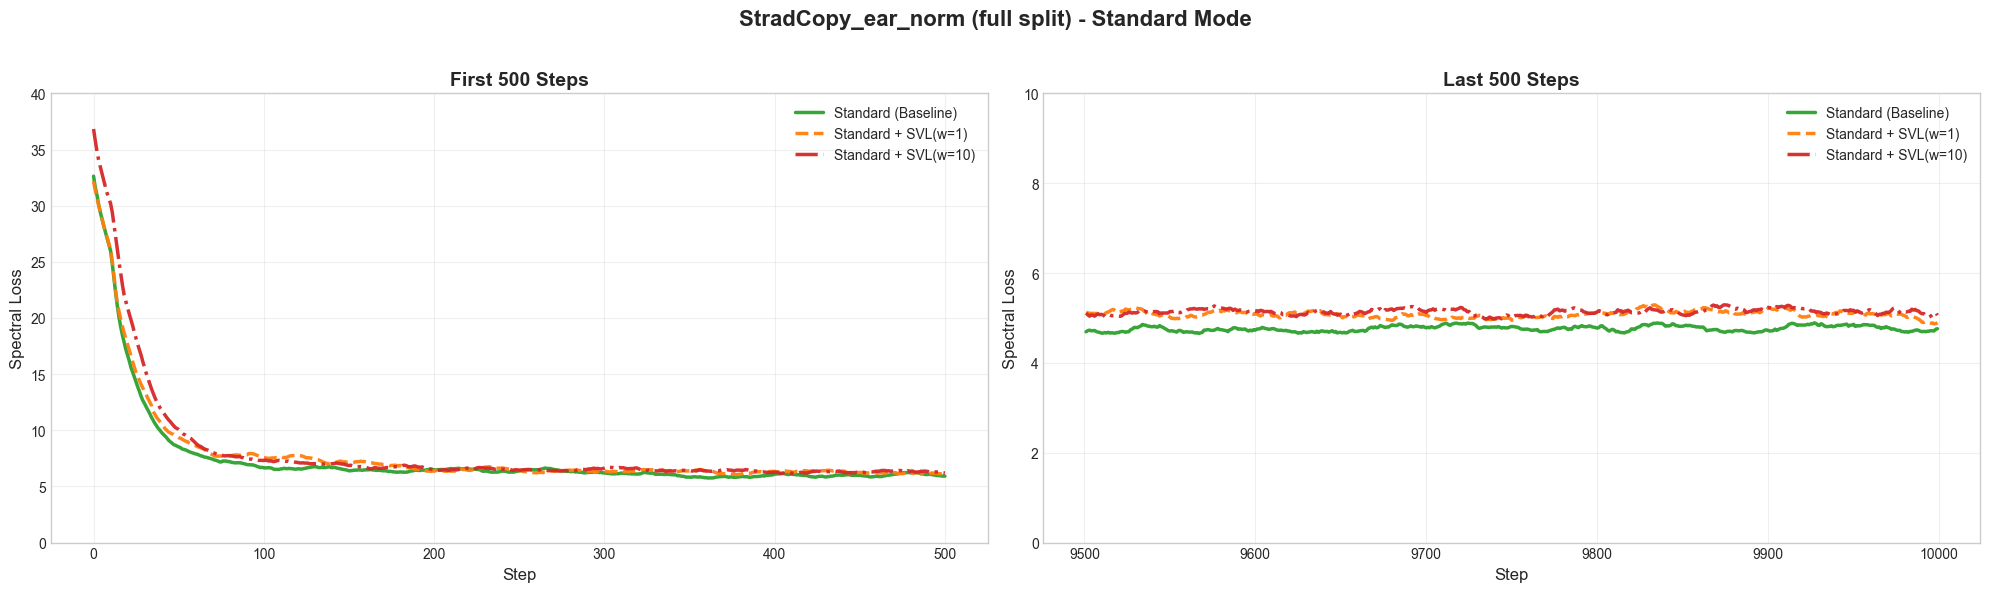


PHYSICS MODE (Full Split): StradCopy_ear_norm
  ✓ Found 3/3 physics models
    📊 Plot saved: plots/StradCopy_ear_norm_full_Physics_Mode.png


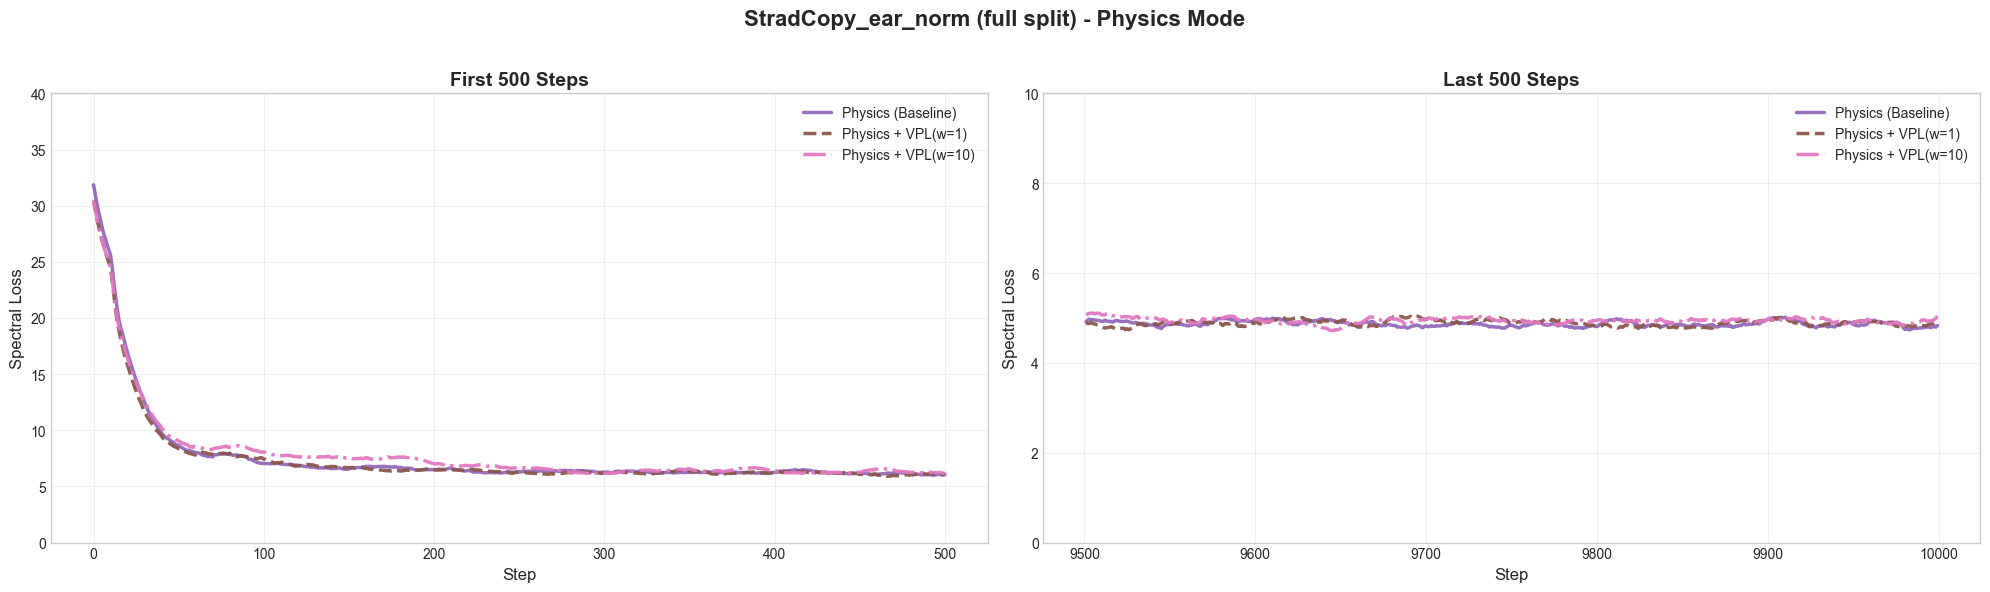


PHYSICS MODE (Per-String): StradCopy_ear_norm

  String A:
    ✓ Found 3/3 models
    📊 Plot saved: plots/StradCopy_ear_norm_A_Physics_Mode_String_A.png


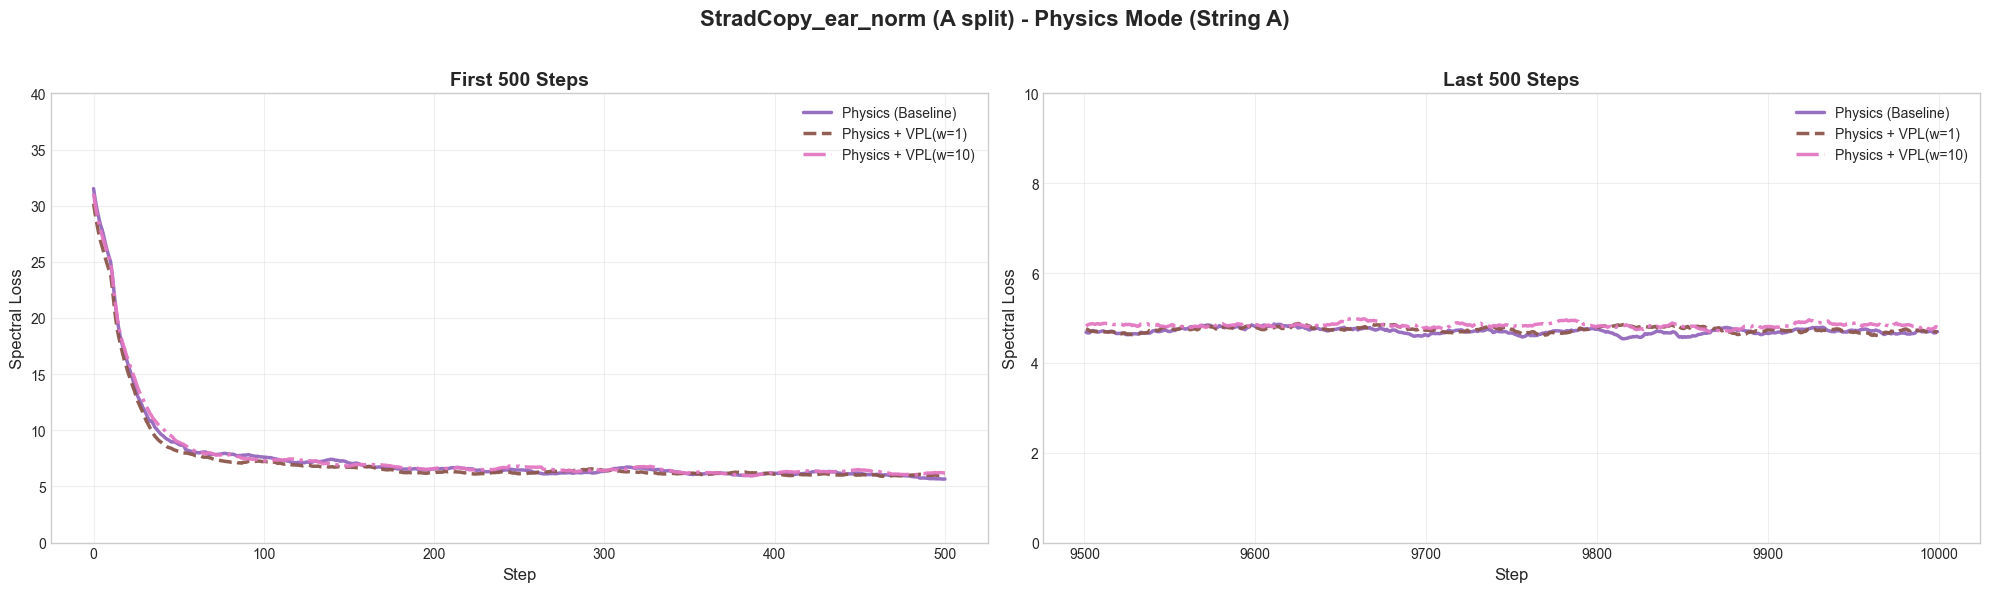


  String D:
    ✓ Found 3/3 models
    📊 Plot saved: plots/StradCopy_ear_norm_D_Physics_Mode_String_D.png


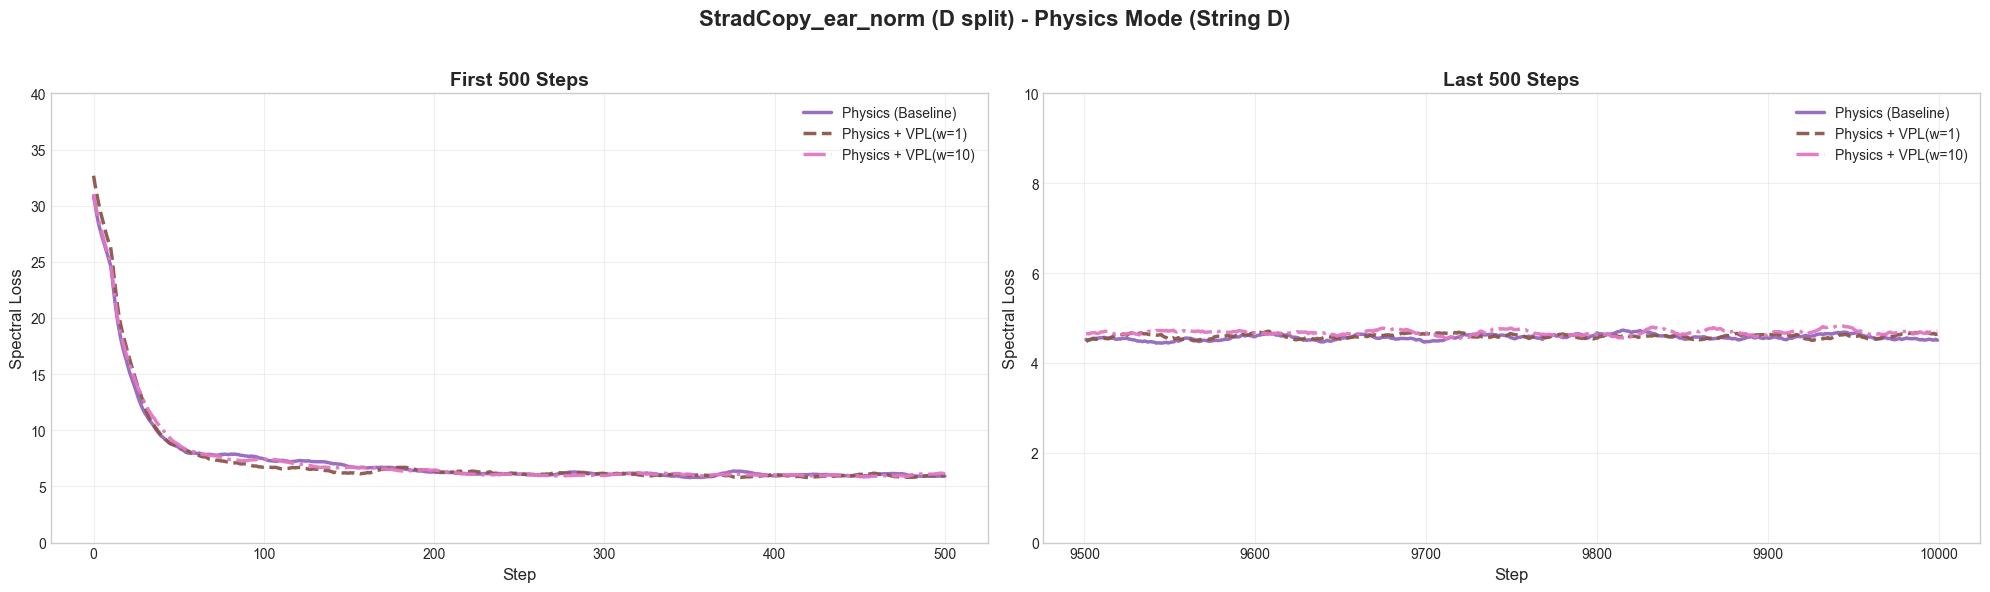


  String E:
    ✓ Found 3/3 models
    📊 Plot saved: plots/StradCopy_ear_norm_E_Physics_Mode_String_E.png


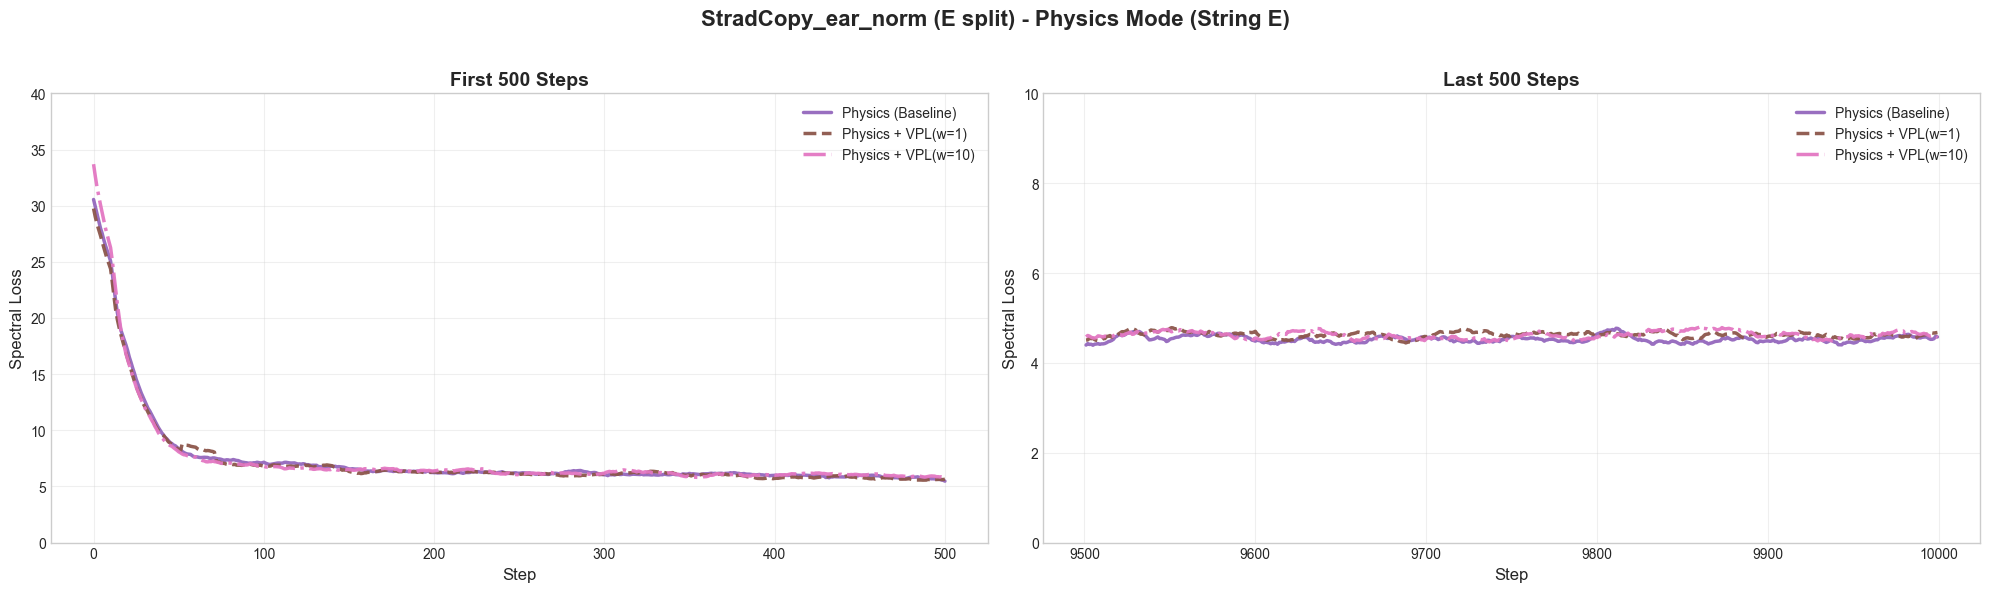


  String G:
    ✓ Found 3/3 models
    📊 Plot saved: plots/StradCopy_ear_norm_G_Physics_Mode_String_G.png


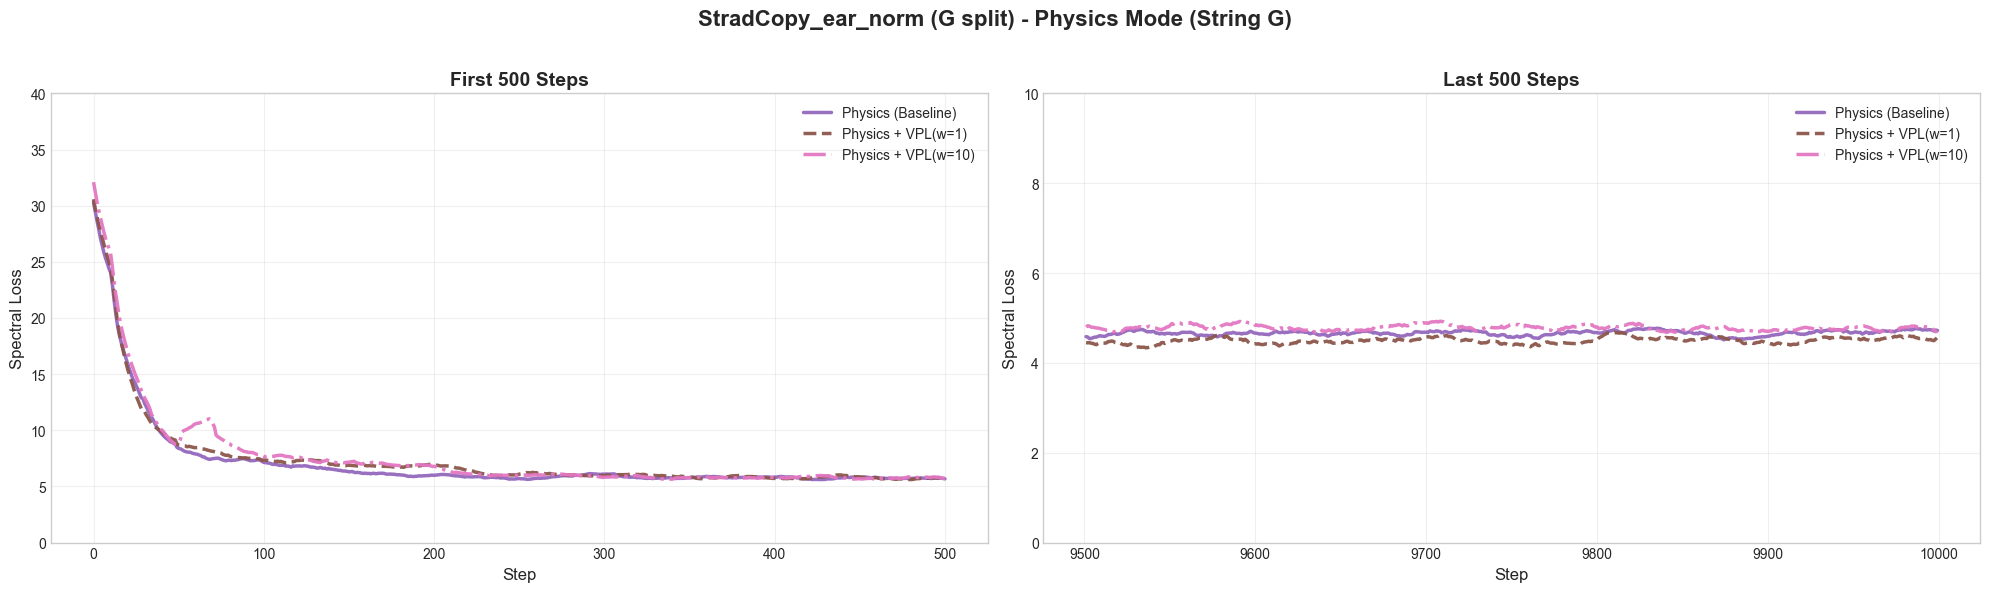


Summary for StradCopy_ear_norm:
  Standard (full): ✓
  Physics (full): ✓
  Physics (per-string): ✓


True

In [4]:
analyze_variation('StradCopy_ear_norm') 